<a href="https://colab.research.google.com/github/hosseinayoubi/Report/blob/main/PatientNoShowProjectFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Patient Appointment No-Show Prediction
**Applied Analytics & AI Mini Project**  
**Abdolhossein (Benjamin) Ayoubi**

This notebook is the technical record for the same project described in my final report. I use the same section order, the same numbers, and the same interpretation. The saved outputs come from the final run. If I rerun the notebook in Colab, it reads the same CSV from GitHub and regenerates the analysis.

## 1. Project Overview and Scope

Some patients miss scheduled medical appointments. That leaves unused capacity and makes planning harder.

My objective is simple: find patterns linked to no-shows and test whether a small classification workflow can flag higher-risk appointments.

I keep the scope narrow. I clean the data, explore a few useful patterns, compare four models, check thresholds, and review responsible use. I do not treat this as a production hospital system, and I do not claim that the model proves why a patient misses an appointment.

## 2. Problem and Success Criteria

**Research question:** Can appointment-level data identify patients with a higher probability of missing a scheduled visit?

I use `No-show = Yes` as the positive class.

I did not set a fixed numeric target before modeling. I use the majority-class dummy model as the reference and focus on metrics that actually reflect no-show detection:

| Objective | KPI / success measure | Decision rule |
|---|---|---|
| Catch likely no-shows | Recall and F1 | Beat the dummy baseline and keep recall useful for reminders |
| Separate risk beyond chance | ROC-AUC | Higher than the 0.50 dummy baseline |
| Keep false alarms visible | Precision and confusion matrix | Report the trade-off, not accuracy alone |
| Check responsible use | Subgroup recall and governance review | No automatic patient decisions |

## 3. Data and Preparation

I use the public **Medical Appointment No Shows** dataset from Kaggle.

For Colab, I read the CSV directly from my GitHub repository. The `raw.githubusercontent.com` link points to the file itself, which is what pandas needs.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_URL = "https://raw.githubusercontent.com/hosseinayoubi/Report/main/Patient_No_Show-KaggleV2-May-2016.csv"

# The local path only helps when I test the notebook outside Colab.
local_paths = [
    Path("Patient_No_Show-KaggleV2-May-2016.csv"),
    Path("/mnt/data/Patient_No_Show-KaggleV2-May-2016.csv")
]
local_file = next((p for p in local_paths if p.exists()), None)

raw = pd.read_csv(local_file if local_file else DATA_URL)
print(f"Loaded {len(raw):,} rows")
raw.head()

Loaded 110,527 rows


I check the obvious problems first: missing values, exact duplicates, impossible ages, and negative waiting time. I keep age 0 because it can represent infants.

In [2]:
df = raw.copy()

df["ScheduledDay_dt"] = pd.to_datetime(df["ScheduledDay"])
df["AppointmentDay_dt"] = pd.to_datetime(df["AppointmentDay"])
df["waiting_days"] = (
    df["AppointmentDay_dt"].dt.normalize()
    - df["ScheduledDay_dt"].dt.normalize()
).dt.days

quality_check = pd.DataFrame({
    "Check": ["Original rows", "Missing values", "Exact duplicate rows", "Age below 0", "Negative waiting days"],
    "Result": [len(df), df.isna().sum().sum(), df.duplicated().sum(), (df["Age"] < 0).sum(), (df["waiting_days"] < 0).sum()]
})
quality_check

                   Check  Result
0          Original rows  110527
1         Missing values       0
2   Exact duplicate rows       0
3            Age below 0       1
4  Negative waiting days       5

In [3]:
clean = df[(df["Age"] >= 0) & (df["waiting_days"] >= 0)].copy()

clean["no_show"] = (clean["No-show"] == "Yes").astype(int)
clean["appointment_weekday"] = clean["AppointmentDay_dt"].dt.day_name()
clean["scheduled_weekday"] = clean["ScheduledDay_dt"].dt.day_name()
clean["scheduled_hour"] = clean["ScheduledDay_dt"].dt.hour
clean["appointment_month"] = clean["AppointmentDay_dt"].dt.month

print(f"Rows after cleaning: {len(clean):,}")
print(f"Rows removed: {len(raw) - len(clean)}")
print(f"Appointment year: {clean['AppointmentDay_dt'].dt.year.min()} to {clean['AppointmentDay_dt'].dt.year.max()}")

Rows after cleaning: 110,521
Rows removed: 6
Appointment year: 2016 to 2016


I leave `AppointmentID` out because it is only an identifier. I use `PatientId` only for the train/test split. I also leave `Neighbourhood` out of the final model because location can act as a proxy for social or geographic factors.

## 4. Exploratory Analysis

I start with the target, then look at waiting time, age, gender, and SMS. These are simple checks, but they help me decide what matters before modeling.

In [4]:
class_balance = clean["No-show"].value_counts().rename_axis("Outcome").to_frame("Count")
class_balance["Percent"] = (class_balance["Count"] / len(clean) * 100).round(2)
class_balance

         Count  Percent
Outcome                
No       88207    79.81
Yes      22314    20.19

In [5]:
clean["waiting_group"] = pd.cut(
    clean["waiting_days"],
    bins=[-0.1, 0, 3, 7, 14, 30, 60, np.inf],
    labels=["Same day", "1-3 days", "4-7 days", "8-14 days", "15-30 days", "31-60 days", "61+ days"]
)

waiting_table = clean.groupby("waiting_group", observed=False)["no_show"].agg(["count", "mean"])
waiting_table["no_show_rate_percent"] = (waiting_table["mean"] * 100).round(2)
waiting_table[["count", "no_show_rate_percent"]]

               count  no_show_rate_percent
waiting_group                             
Same day       38562                  4.65
1-3 days       14675                 22.89
4-7 days       17510                 25.20
8-14 days      12025                 30.47
15-30 days     17371                 32.59
31-60 days      8283                 34.15
61+ days        2095                 28.45

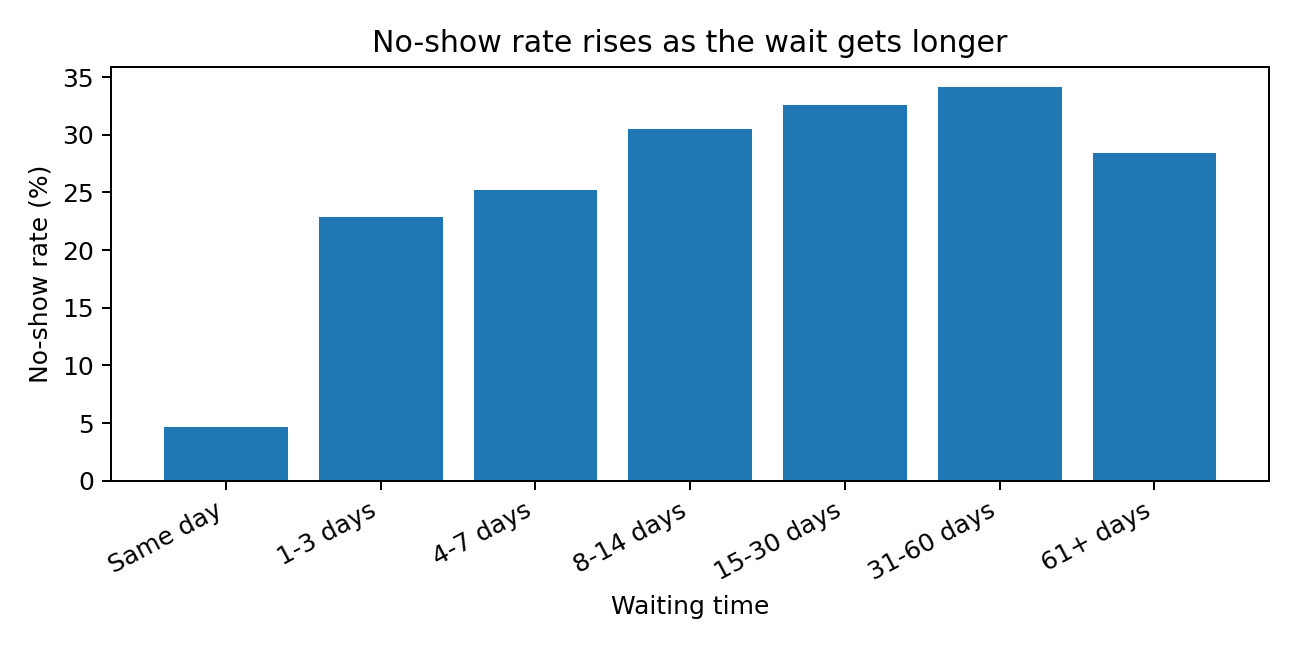

In [6]:
ax = waiting_table["no_show_rate_percent"].plot(kind="bar", figsize=(8, 4), title="No-show rate by waiting time")
ax.set_xlabel("Waiting time")
ax.set_ylabel("No-show rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Waiting time is the clearest early pattern. Same-day appointments have the lowest no-show rate, while the 31 to 60 day group is much higher. I treat this as an association, not proof of cause and effect.

In [7]:
clean["age_group"] = pd.cut(
    clean["Age"], bins=[-0.1, 5, 17, 29, 44, 59, np.inf],
    labels=["0-5", "6-17", "18-29", "30-44", "45-59", "60+"]
)

age_table = clean.groupby("age_group", observed=False)["no_show"].mean().mul(100).round(2).to_frame("no_show_rate_percent")
gender_table = clean.groupby("Gender")["no_show"].mean().mul(100).round(2).to_frame("no_show_rate_percent")
sms_table = clean.groupby("SMS_received")["no_show"].mean().mul(100).round(2).to_frame("no_show_rate_percent")

print("Age")
display(age_table)
print("Gender")
display(gender_table)
print("SMS")
display(sms_table)

Age
           no_show_rate_percent
age_group                      
0-5                       18.63
6-17                      24.36
18-29                     24.64
30-44                     21.82
45-59                     17.87
60+                       15.31

Gender
        no_show_rate_percent
Gender                      
F                      20.31
M                      19.96

SMS
              no_show_rate_percent
SMS_received                      
0                            16.70
1                            27.57

The 18 to 29 group has the highest no-show rate, with ages 6 to 17 close behind. Gender barely changes the rate.

The SMS result looks surprising. Patients who received an SMS show a higher observed no-show rate. I do not read that as evidence that SMS messages cause no-shows because the reminders were probably not assigned randomly.

## 5. Method / Workflow

I keep the modeling stage straightforward so I can explain every step.

1. Split the data 70/30 by `PatientId`.
2. Prepare numeric and categorical features inside one pipeline.
3. Compare a dummy baseline, Logistic Regression, Decision Tree, and Random Forest.
4. Use class weighting for the three trained classifiers.
5. Evaluate recall, precision, F1, ROC-AUC, confusion matrix, thresholds, feature importance, and subgroup recall.

In [8]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

features = [
    "Gender", "Age", "Scholarship", "Hipertension", "Diabetes", "Alcoholism",
    "Handcap", "SMS_received", "waiting_days", "scheduled_hour",
    "appointment_weekday", "scheduled_weekday", "appointment_month"
]

X = clean[features]
y = clean["no_show"]
groups = clean["PatientId"]

split = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, test_idx = next(split.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train rows: {len(X_train):,}")
print(f"Test rows:  {len(X_test):,}")

Train rows: 77,565
Test rows:  32,956


In [9]:
numeric_features = [
    "Age", "Scholarship", "Hipertension", "Diabetes", "Alcoholism", "Handcap",
    "SMS_received", "waiting_days", "scheduled_hour", "appointment_month"
]
categorical_features = ["Gender", "appointment_weekday", "scheduled_weekday"]

preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("fill", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("fill", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

models = {
    "Dummy baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear", random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, min_samples_leaf=100, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=120, max_depth=10, min_samples_leaf=50, class_weight="balanced_subsample", random_state=42, n_jobs=-1)
}

## 6. Results

I run the same preprocessing for every model and compare them on the same test set.

In [10]:
results = []
fitted = {}

for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:, 1]
    cm = confusion_matrix(y_test, pred)

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, prob),
        "tn": cm[0,0], "fp": cm[0,1], "fn": cm[1,0], "tp": cm[1,1]
    })
    fitted[name] = (pipe, pred, prob)

metrics = pd.DataFrame(results)
metrics[["model", "accuracy", "precision", "recall", "f1", "roc_auc"]].round(3)

                 model  accuracy  precision  recall     f1  roc_auc
0       Dummy baseline     0.796      0.000   0.000  0.000    0.500
1  Logistic Regression     0.663      0.320   0.574  0.410    0.669
2        Decision Tree     0.573      0.303   0.835  0.444    0.725
3        Random Forest     0.573      0.304   0.845  0.447    0.728

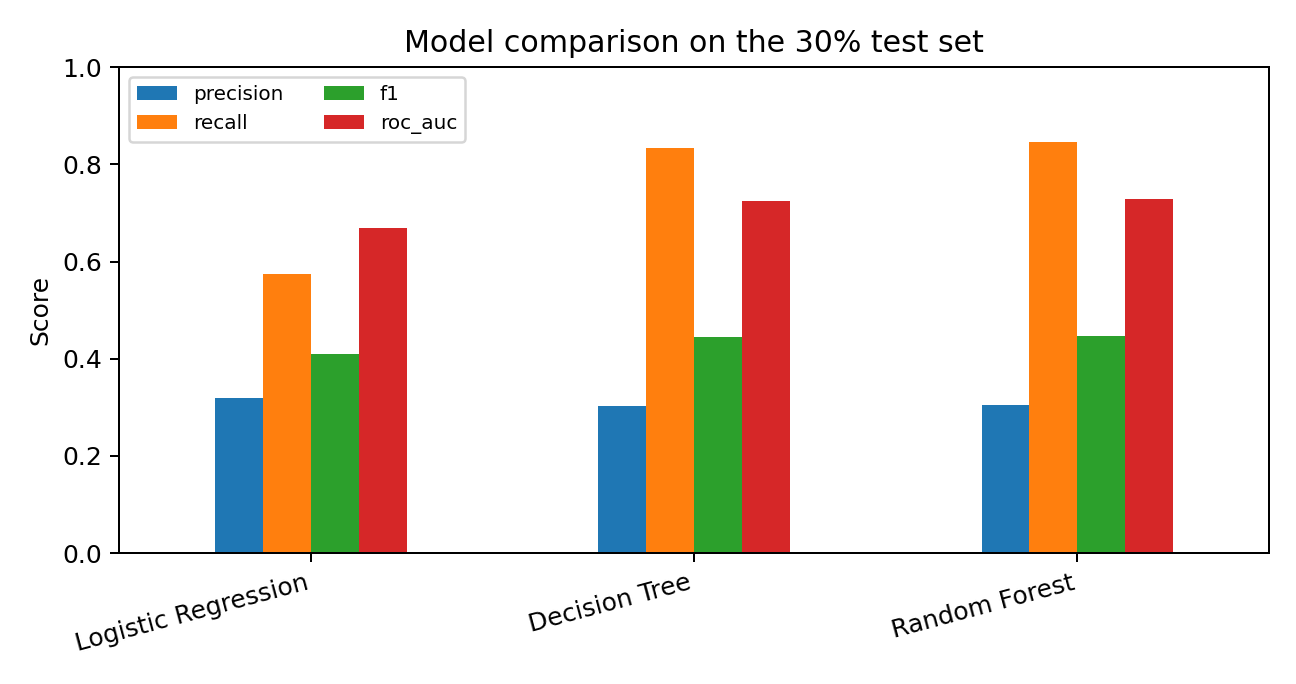

In [11]:
plot_metrics = metrics.set_index("model")[["precision", "recall", "f1", "roc_auc"]]
ax = plot_metrics.plot(kind="bar", figsize=(9, 4.5))
ax.set_title("Model comparison on the 30% test set")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [12]:
best_name = metrics.loc[metrics["f1"].idxmax(), "model"]
best_pipe, best_pred, best_prob = fitted[best_name]
cm = confusion_matrix(y_test, best_pred)

print("Best model by no-show F1:", best_name)
print(pd.DataFrame(cm, index=["Actual show", "Actual no-show"], columns=["Predicted show", "Predicted no-show"]))

Best model by no-show F1: Random Forest
                Predicted show  Predicted no-show
Actual show              13201              13020
Actual no-show            1043               5692


In [13]:
rf_pipe = fitted["Random Forest"][0]
feature_names = rf_pipe.named_steps["prep"].get_feature_names_out()
importance = rf_pipe.named_steps["model"].feature_importances_

feature_importance = (
    pd.DataFrame({"feature": feature_names, "importance": importance})
    .sort_values("importance", ascending=False)
    .head(8)
)
feature_importance

                             feature  importance
7                  num__waiting_days    0.692815
0                           num__Age    0.079240
6                  num__SMS_received    0.064756
8                num__scheduled_hour    0.037186
22    cat__scheduled_weekday_Tuesday    0.011485
18     cat__scheduled_weekday_Friday    0.011168
23  cat__scheduled_weekday_Wednesday    0.010753
2                  num__Hipertension    0.010037

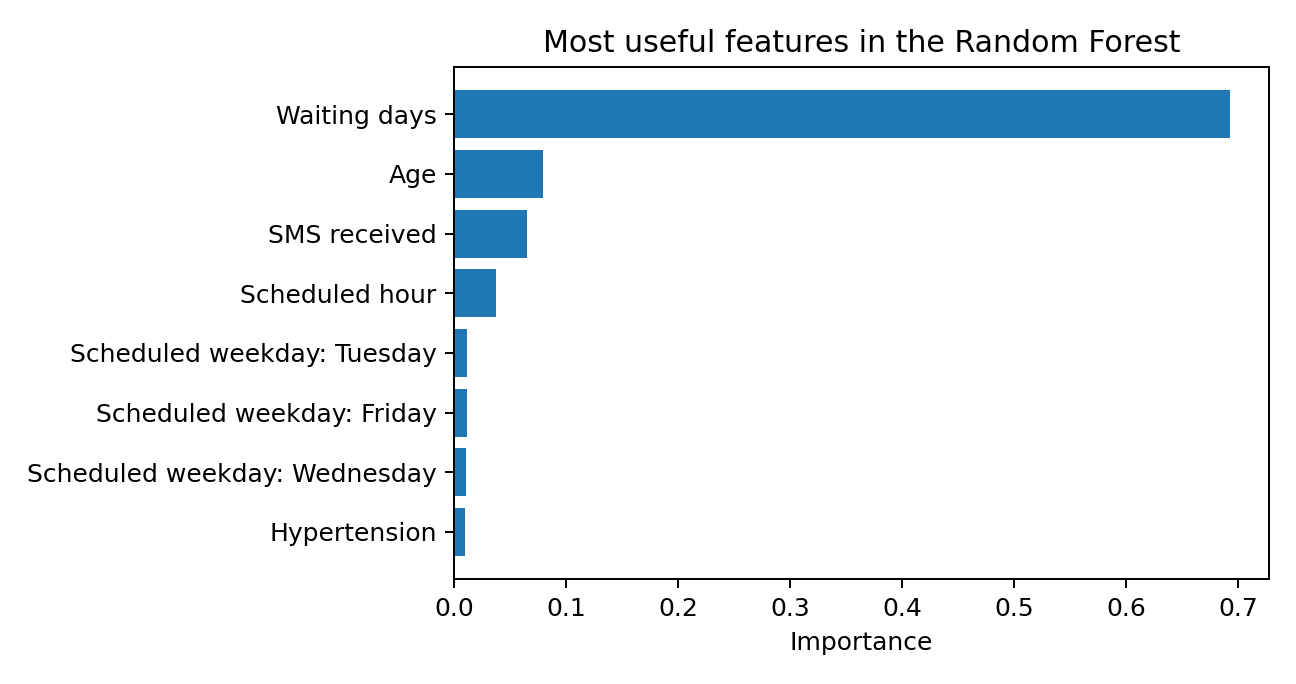

In [14]:
plot_importance = feature_importance.sort_values("importance")
ax = plot_importance.plot(x="feature", y="importance", kind="barh", figsize=(8, 4.5), legend=False, title="Top Random Forest feature importances")
ax.set_xlabel("Importance")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 7. Discussion and Interpretation

The dummy baseline looks accurate because most appointments are shows, but it finds zero no-shows. That makes the accuracy score pretty misleading here.

Random Forest gives the best no-show F1 score. Recall is 0.845, so it catches about 84.5% of actual no-shows in the test set. Precision is only 0.304. In plain language, many appointments flagged by the model would still be attended.

That trade-off can make sense for a low-cost reminder. It does not make sense for a decision that affects access to care.

In [15]:
threshold_rows = []
for threshold in [0.30, 0.40, 0.50, 0.60]:
    pred_t = (best_prob >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_test, pred_t, zero_division=0),
        "recall": recall_score(y_test, pred_t, zero_division=0),
        "f1": f1_score(y_test, pred_t, zero_division=0),
        "flagged_percent": pred_t.mean() * 100
    })
threshold_table = pd.DataFrame(threshold_rows)
threshold_table.round(3)

   threshold  precision  recall     f1  flagged_percent
0        0.3      0.287   0.932  0.439           66.249
1        0.4      0.288   0.921  0.439           65.272
2        0.5      0.304   0.845  0.447           56.779
3        0.6      0.353   0.521  0.421           30.216

Lower thresholds catch more no-shows but flag many more appointments. At 0.60, precision improves, but recall falls sharply. I would choose the threshold only after knowing the real cost of a missed appointment and an unnecessary reminder.

The exploratory and modeling results point in the same direction on waiting time. The SMS result is different. It is interesting, but I treat it as an observational pattern, not a causal claim.

The main limits are straightforward: one historical dataset, no external validation, no real cost study, and no extensive tuning. A real next step would be testing the same workflow on newer local data.

## 8. Governance, Privacy, and Security

I keep the intended use low-risk. A prediction can support reminders, confirmations, or easier rescheduling. It should not cancel appointments, lower patient priority, or reduce access automatically.

In [16]:
test_check = clean.iloc[test_idx][["Gender", "Age"]].copy()
test_check["actual"] = y_test.values
test_check["predicted"] = best_pred

test_check["age_group"] = pd.cut(
    test_check["Age"], bins=[-0.1, 5, 17, 29, 44, 59, np.inf],
    labels=["0-5", "6-17", "18-29", "30-44", "45-59", "60+"]
)

rows = []
for column in ["Gender", "age_group"]:
    for group_name, group in test_check.groupby(column, observed=False):
        rows.append({
            "group_type": column,
            "group": str(group_name),
            "rows": len(group),
            "actual_no_shows": int(group["actual"].sum()),
            "recall": recall_score(group["actual"], group["predicted"], zero_division=0)
        })

fairness_table = pd.DataFrame(rows)
fairness_table.round(3)

  group_type  group   rows  actual_no_shows  recall
0     Gender      F  21494             4409   0.856
1     Gender      M  11462             2326   0.824
2  age_group    0-5   3478              650   0.942
3  age_group   6-17   4763             1184   0.823
4  age_group  18-29   4862             1191   0.927
5  age_group  30-44   6488             1421   0.942
6  age_group  45-59   7013             1287   0.830
7  age_group    60+   6352             1002   0.593

The age gap is the part I would watch most closely. Recall for patients aged 60+ is 0.593, much lower than several younger groups. That does not prove unfairness by itself, but it is a clear warning sign.

**Privacy:** I use a public course dataset here. Real patient data would need data minimization, controlled access, and suitable anonymization or pseudonymization.

**Security:** a public GitHub repository is fine for this public dataset. I would never upload confidential patient data there.

**Governance:** the dataset source and project process are documented. A real organization would still need to confirm data ownership, licensing, and permission before processing.

## 9. Conclusion

I completed the main objective. The workflow cleans the data, finds useful patterns, compares several models, and checks the best model across thresholds and patient groups.

Random Forest performs best for the no-show class, with recall **0.845**, F1 **0.447**, and ROC-AUC **0.728**. The model catches many no-shows, but precision is limited. I see it as a support tool for reminders and scheduling, not an automatic decision system.

The next practical step is to test the same workflow on newer local data.

## 10. References

1. Kaggle. *Medical Appointment No Shows* dataset. https://www.kaggle.com/datasets/joniarroba/noshowappointments
2. Metropolia University of Applied Sciences. *Applied Analytics & AI* course materials and mini-project guidance, 2026.
3. Python Software Foundation. https://www.python.org/
4. pandas. https://pandas.pydata.org/
5. NumPy. https://numpy.org/
6. scikit-learn. https://scikit-learn.org/
7. Matplotlib. https://matplotlib.org/
8. Google Colab. https://colab.research.google.com/
9. GitHub project repository. https://github.com/hosseinayoubi/Report

### AI Use Declaration

I carried out the main parts of the project myself, including data cleaning, feature preparation, model selection, evaluation, and interpretation of the results. I used AI as a supporting tool for occasional coding help and language editing. I reviewed the code, reran the notebook, checked the outputs, and made the final decisions about the methods, results, and conclusions.